<a href="https://colab.research.google.com/github/Awimya-Rn/PCVK26_13_Ilham/blob/main/Week3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [27]:
import datetime
import zoneinfo
from IPython.core.async_helpers import sys
import platform
import hashlib
import matplotlib.pyplot as plt
import cv2 as cv
import numpy as np
import math
from google.colab.patches import cv2_imshow

In [28]:
NAMA='Mokhammad Ilham Putra Wijaya'
NIM='244107020139'

N=int(NIM[-3:])
PARAM={
    'b':(N%61)+20,
    'a':round(1+(N%9)/10,1),
    'c':(N%20)+30,
    'gamma':round(0.4+(N%6)*0.25,2),
    'bit':(N%6)+2
}
waktu=datetime.datetime.now(zoneinfo.ZoneInfo('Asia/Jakarta'))

print('NAMA   :',NAMA)
print('NIM    :',NIM)
for k,v in PARAM.items():
  print('%-6s :' % k, v)
print('WAKTU  :', waktu.strftime('%Y-%m-%d %H:%M:%S %Z'))
print('SISTEM :',sys.version.split()[0],platform.platform())
kunci = NIM + '|' + waktu.strftime('%Y-%m-%d')
print('TOKEN  :',hashlib.sha256(kunci.encode()).hexdigest()[:16])

NAMA   : Mokhammad Ilham Putra Wijaya
NIM    : 244107020139
b      : 37
a      : 1.4
c      : 49
gamma  : 0.65
bit    : 3
WAKTU  : 2026-09-17 20:19:11 WIB
SISTEM : 3.13.15 Linux-6.6.122+-x86_64-with-glibc2.39
TOKEN  : 029699386d8ce68b


Text(0.5, 1.0, '244107020139 - gamma 0.65')

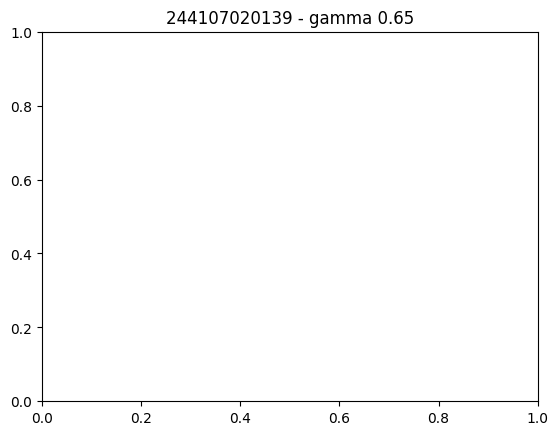

In [29]:
plt.title(NIM + ' - gamma ' + str(PARAM['gamma']))

# PRAKTIKUM

## Operasi Citra Sederhana

In [30]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## transformasi linier brightness

/tmp/ipykernel_24921/197289265.py:16: RuntimeWarning: overflow encountered in scalar add
  brightness_image[y,x,c] = np.clip(original[y,x,c] + brightness, 0, 255)


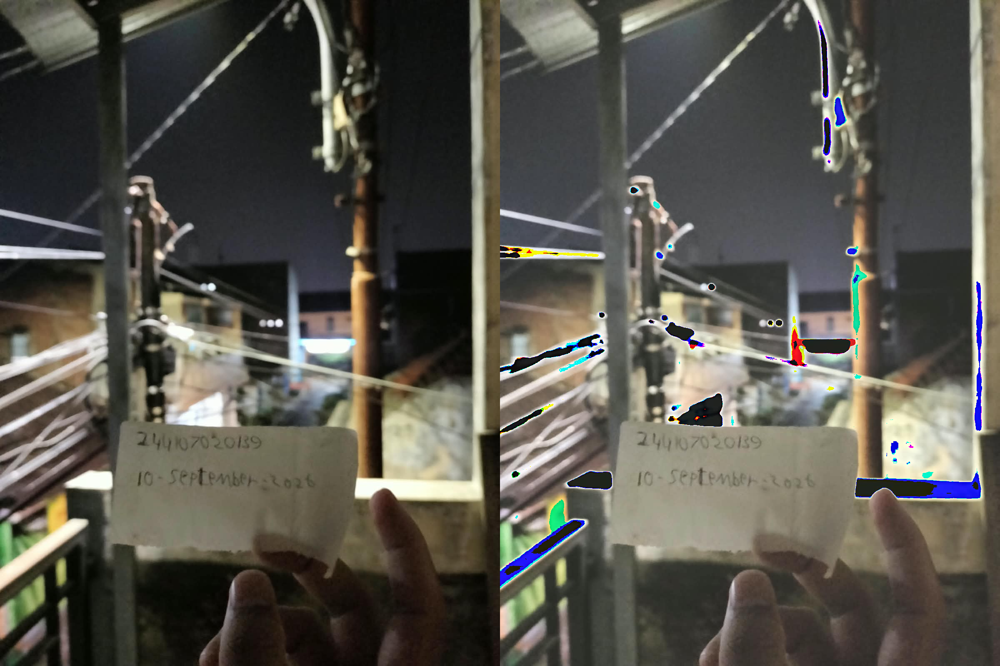

In [31]:
import os

brightness=PARAM['b']
image_path = '/content/drive/MyDrive/PCVK/Images/244107020139/NIGHT1.jpeg'
original = cv.imread(image_path)

if original is None:
    print(f"Error: Gambar tidak dapat dimuat dari path: {image_path}")
    print("Pastikan Anda telah memasang (mount) Google Drive dan gambar berada di folder yang benar.")
else:
    brightness_image = np.zeros(original.shape, original.dtype)

    for y in range(original.shape[0]):
      for x in range(original.shape[1]):
        for c in range(original.shape[2]):
          brightness_image[y,x,c] = np.clip(original[y,x,c] + brightness, 0, 255)

    final_frame = cv.hconcat((original, brightness_image))
    cv2_imshow(final_frame)

# TUGAS PRAKTIKUM

# 1. Implementasikan inverse citra pada Google Colaboratory menggunakan formula pada bagian Ulasan Teori. Terapkan pada KTM1b.jpg dan KTM1a.jpg, tampilkan berdampingan dengan citra aslinya. Jelaskan mengapa citra negatif dari KTM1a (ruangan gelap) tampak pucat dan berkabut, sedangkan negatif dari KTM1b tetap kontras.

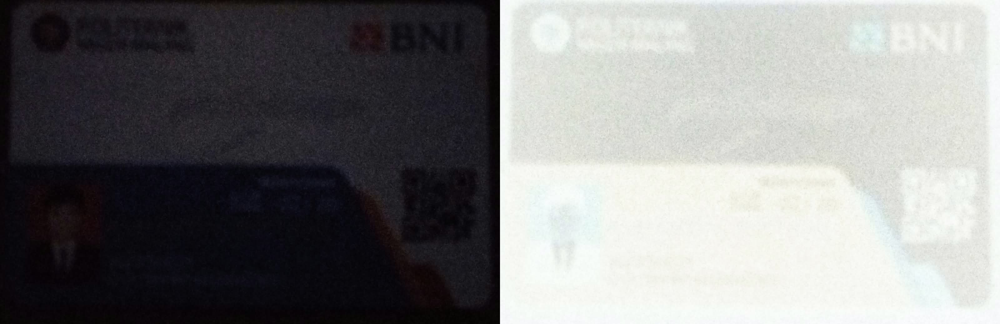

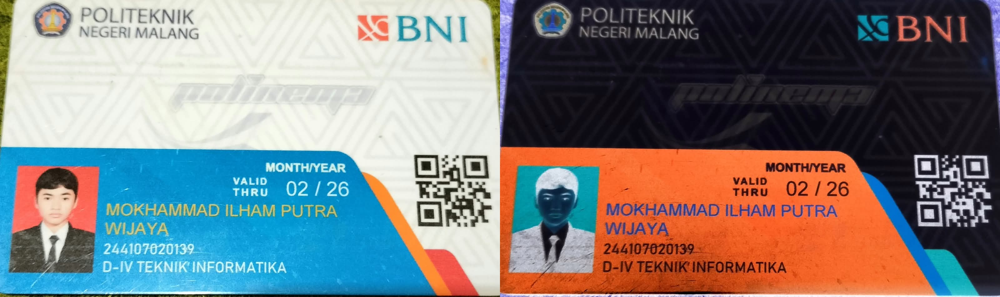

In [32]:
img_ktm1a=f'/content/drive/MyDrive/PCVK/Images/244107020139/KTM1a.jpeg'
img_ktm1b=f'/content/drive/MyDrive/PCVK/Images/244107020139/KTM1b.jpeg'

img_ktm1a=cv.imread(img_ktm1a)
img_ktm1b=cv.imread(img_ktm1b)

def inverse_citra(img):
  return 255 - img

img_inverse_ktm1a=inverse_citra(img_ktm1a)
img_inverse_ktm1b=inverse_citra(img_ktm1b)

final_frame = cv.hconcat((img_ktm1a, img_inverse_ktm1a))
cv2_imshow(final_frame)

final_frame = cv.hconcat((img_ktm1b, img_inverse_ktm1b))
cv2_imshow(final_frame)

Citra KTM1a diambil dalam kondisi minim cahaya, sehingga menghasilkan histogram sempit dengan nilai-nilai yang terkonsentrasi di ujung bawah (di sekitar angka 0). Kontras awalnya pun rendah; pembalikan histogram menggeser nilai-nilai rendah tersebut ke nilai yang lebih tinggi (di sekitar angka 255), sehingga keseluruhan citra beralih ke rentang kecerahan yang lebih tinggi. Namun, nilai-nilai tersebut tetap terkonsentrasi dalam rentang yang sempit, sehingga tidak ada peningkatan kontras dan citra tampak berkabut serta keputihan. Sebaliknya, citra KTM1b diambil dalam kondisi pencahayaan yang baik. Histogramnya telah mencakup rentang yang luas. Pembalikan histogram hanya membalikkan posisi nilai-nilai tersebut tanpa mengubah lebar distribusinya, sehingga kontras citra tetap terjaga.

# 2. Implementasikan transformasi kontras dengan nilai a yang dihitung dari NIM Anda (PARAM['a']) pada KTM1a.jpg.

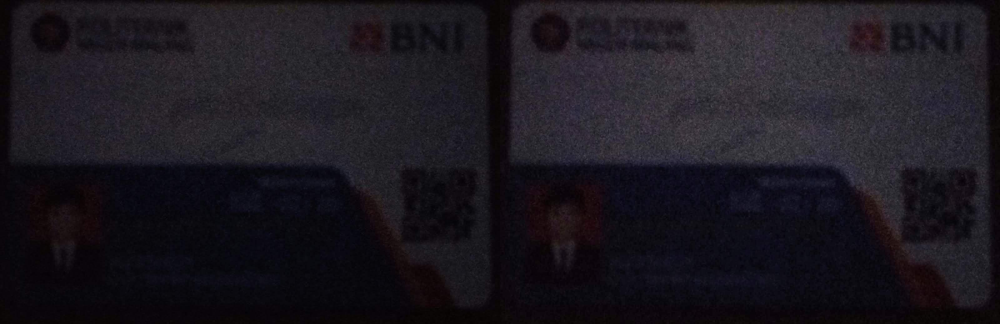

In [33]:
def kontras(img,a,b=0):
  out=a*img.astype(np.float32)+b
  return np.clip(out,0,255).astype(np.uint8)

img_kontras_ktm1a=kontras(img_ktm1a,PARAM['a'])
final_frame = cv.hconcat((img_ktm1a, img_kontras_ktm1a))
cv2_imshow(final_frame)

Karena a = PARAM['a'] > 1, semua nilai piksel ditingkatkan skalanya lebih kuat, sehingga meningkatkan rentang histogram (dan meningkatkan kontras). Akibatnya, piksel yang sudah terang dengan cepat mencapai nilai 255, yang menyebabkan pemotongan dan potensi kehilangan detail di area terang pada gambar KTM.

# 3. Implementasikan transformasi logarithmic brightness dengan konstanta c hasil hitung dari NIM (PARAM['c']) pada KTM1a.jpg. Bandingkan hasilnya dengan linier brightness memakai nilai b hasil hitung dari NIM (PARAM['b']) pada citra yang sama. Tentukan metode mana yang membuat NIM pada kartu Anda lebih terbaca, dan tunjukkan bagian mana yang menjadi putih penuh (clipping) pada masing-masing metode.

/tmp/ipykernel_24921/4158670636.py:3: RuntimeWarning: divide by zero encountered in log
  return np.clip(c*np.log(f32),0,255).astype(np.uint8)


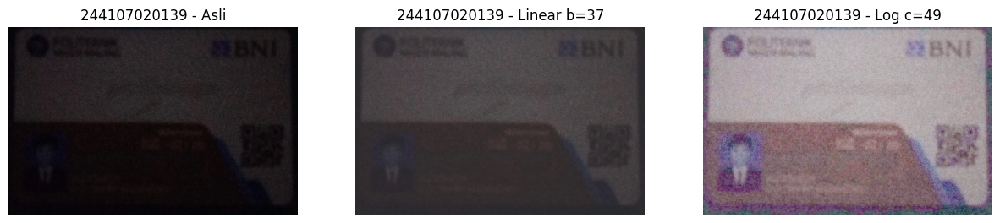

In [34]:
def log_brightness(img,c):
  f32=img.astype(np.float32)
  return np.clip(c*np.log(f32),0,255).astype(np.uint8)

def lin_brightness(img,b):
  f32=img.astype(np.int16)
  return np.clip(f32+b,0,255).astype(np.uint8)

img_log_ktm1a=log_brightness(img_ktm1a,PARAM['c'])
img_lin_ktm1a=lin_brightness(img_ktm1a,PARAM['b'])

fig, axs = plt.subplots(1, 3, figsize=(15, 5))
axs[0].imshow(img_ktm1a)
axs[0].set_title(NIM+' - Asli')
axs[1].imshow(img_lin_ktm1a)
axs[1].set_title(NIM+f' - Linear b={PARAM['b']}')
axs[2].imshow(img_log_ktm1a)
axs[2].set_title(NIM+f' - Log c={PARAM['c']}')
for ax in axs:
  ax.axis('off')
plt.show()

Karena properti linear brightness menambahkan nilai yang sama pada setiap piksel, area yang sudah terang dapat mencapai nilai maksimum 255, yang mengakibatkan hilangnya detail kecerahan lebih lanjut. Sebaliknya, properti logarithmic brightness, berkat kemiringan kurva logarithmic yang menurun di bagian atas, meningkatkan nilai yang lebih rendah secara lebih signifikan dibandingkan nilai yang lebih tinggi; hal ini sangat meningkatkan visibilitas area peta yang gelap tanpa membuat area terang menjadi terlalu jenuh.

# 4. Implementasikan transformasi grayscale metode averaging, lightness, dan luminance pada KTM1c.jpg, yaitu citra yang diambil dengan flash. Hitung rata-rata dan simpangan baku intensitas hasil ketiga metode, sajikan dalam satu tabel, lalu tentukan metode mana yang memberi pemisahan paling jelas antara teks dan latar kartu.

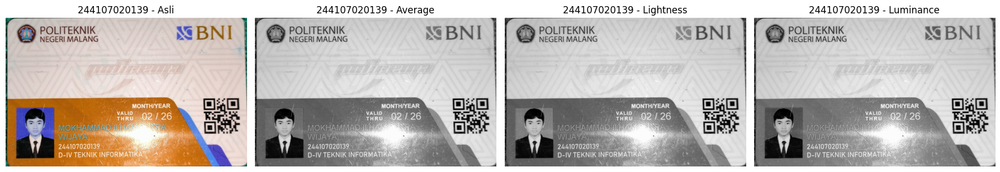

In [35]:
def gray_avg(img):
  return np.mean(img.astype(np.float32),axis=-1).astype(np.uint8)

def gray_lightness(img):
  r = img[:, :, 0].astype(float)
  g = img[:, :, 1].astype(float)
  b = img[:, :, 2].astype(float)

  max_val = np.maximum(np.maximum(r, g), b)
  min_val = np.minimum(np.minimum(r, g), b)
  lightness = (max_val + min_val) / 2.0
  return lightness.astype(np.uint8)

def gray_luminance(img):
  r = img[:, :, 0].astype(float)
  g = img[:, :, 1].astype(float)
  b = img[:, :, 2].astype(float)

  luminance = 0.299 * r + 0.587 * g + 0.114 * b
  return luminance.astype(np.uint8)

img_ktm1c=cv.imread(f'/content/drive/MyDrive/PCVK/Images/244107020139/KTM1c.jpeg')

img_gray_avg_ktm1c=gray_avg(img_ktm1c)
img_gray_lig_ktm1c=gray_lightness(img_ktm1c)
img_gray_lum_ktm1c=gray_luminance(img_ktm1c)

img_gray_avg_ktm1c_bgr = cv.cvtColor(img_gray_avg_ktm1c, cv.COLOR_GRAY2BGR)
img_gray_lig_ktm1c_bgr = cv.cvtColor(img_gray_lig_ktm1c, cv.COLOR_GRAY2BGR)
img_gray_lum_ktm1c_bgr = cv.cvtColor(img_gray_lum_ktm1c, cv.COLOR_GRAY2BGR)

fig, axs = plt.subplots(1, 4, figsize=(18, 5))
for ax, (judul, im) in zip(axs, [('Asli', img_ktm1c), ('Average', img_gray_avg_ktm1c_bgr), ('Lightness', img_gray_lig_ktm1c_bgr), ('Luminance', img_gray_lum_ktm1c_bgr)]):
  ax.imshow(im)
  ax.set_title(NIM+' - '+judul)
  ax.axis('off')
plt.tight_layout()
plt.show()

Metode dengan standar deviasi tertinggi biasanya menghasilkan pemisahan terbaik antara teks dan latar belakang kartu. Hal ini dikarenakan rentang kecerahan yang lebih lebar menghasilkan kontras yang lebih tinggi antara teks (gelap) dan latar belakang (terang). Bandingkan nilai standar deviasi pada tabel dengan nilai dari citra KTM1c Anda untuk memilih metode yang paling sesuai. Selain itu, sebagaimana dijelaskan dalam modul, parameter Rec.601 (yang digunakan dalam cv.cvtColor) ditampilkan sebagai perbandingan dengan standar Rec.709.

# 5. Tampilkan satu warna tertentu pada citra dan ubah bagian lainnya menjadi grayscale. Gunakan OBJ1.jpg, yaitu foto benda milik Anda sendiri dengan satu warna dominan. Sebutkan rentang nilai HSV yang Anda pakai sebagai batas warna, lalu tunjukkan pengaruhnya apabila rentang tersebut diperlebar dan dipersempit.

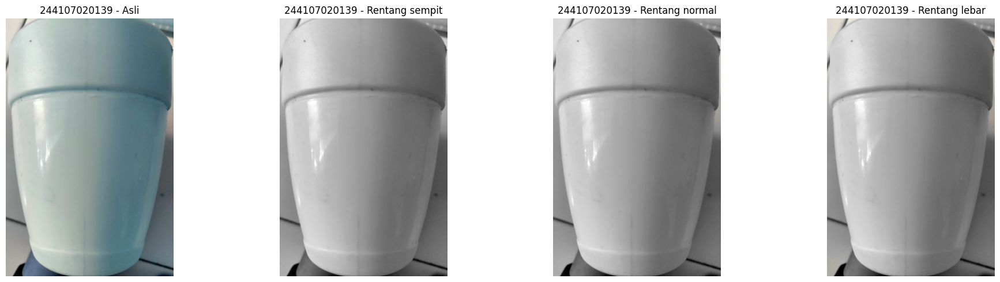

In [36]:
def color_pop(img,lower,upper):
  hsv=cv.cvtColor(img,cv.COLOR_RGB2HSV)
  mask=cv.inRange(hsv,lower,upper)
  gray=cv.cvtColor(img,cv.COLOR_RGB2GRAY)
  gray3=cv.cvtColor(gray,cv.COLOR_GRAY2RGB)
  mask3=cv.cvtColor(mask,cv.COLOR_GRAY2RGB)
  return np.where(mask3==255,img,gray3)

img_obj1=cv.imread(f'/content/drive/MyDrive/PCVK/Images/244107020139/OBJ1.jpeg')

lower_normal = np.array([15, 25, 100])
upper_normal = np.array([35, 180, 255])

lower_sempit = np.array([18, 40, 140])
upper_sempit = np.array([30, 140, 255])

lower_lebar = np.array([10, 15, 70])
upper_lebar = np.array([40, 220, 255])

hasil_normal = color_pop(img_obj1, lower_normal, upper_normal)
hasil_sempit = color_pop(img_obj1, lower_sempit, upper_sempit)
hasil_lebar  = color_pop(img_obj1, lower_lebar,  upper_lebar)

fig, axs = plt.subplots(1, 4, figsize=(20, 5))
for ax, (judul, im) in zip(axs, [('Asli', img_obj1), ('Rentang sempit', hasil_sempit),
                                   ('Rentang normal', hasil_normal), ('Rentang lebar', hasil_lebar)]):
    ax.imshow(im); ax.set_title(NIM+' - '+judul); ax.axis('off')
plt.tight_layout(); plt.show()

# 6. Gamma Correction pada Citra Pribadi Nilai gamma diminta dari pengguna melalui kode di bawah ini. Lanjutkan kode tersebut sesuai rumus pada Ulasan Teori, kemudian terapkan pada KTM1a.jpg. Mulailah dari nilai gamma hasil hitung dari NIM Anda, lalu cari secara bertahap nilai gamma yang membuat NIM dan nama pada kartu paling terbaca. Tampilkan minimal lima nilai gamma yang dicoba beserta hasilnya, sebutkan nilai gamma terbaik pilihan Anda, dan jelaskan mengapa nilai terbaik setiap mahasiswa berbeda meskipun jenis objeknya sama.

 Gamma Correction pada citra 
----------------------------------
Masukkan nilai Gamma: 0.35


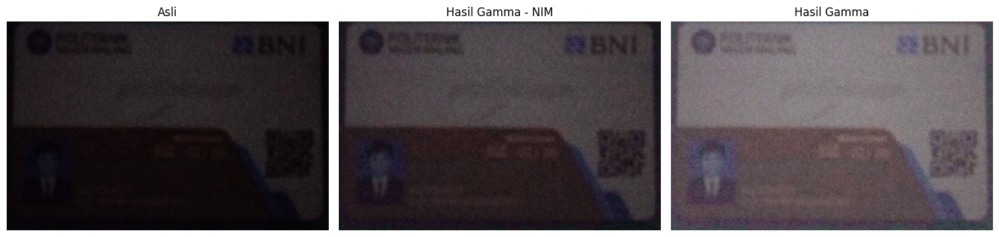

In [37]:
print(' Gamma Correction pada citra ')
print('----------------------------------')
inp_gamma = float(input('Masukkan nilai Gamma: '))

def gamma_correction(img, gamma):
  normm=img.astype(np.float32)/255
  return np.clip(255*(normm**gamma),0,255).astype(np.uint8)

hasil_gamma=gamma_correction(img_ktm1a,inp_gamma)
hasil_gamma_NIM=gamma_correction(img_ktm1a,PARAM['gamma'])

fig, axs = plt.subplots(1, 3, figsize=(15, 5))
for ax, (judul, im) in zip(axs, [('Asli', img_ktm1a), ('Hasil Gamma - NIM', hasil_gamma_NIM), ('Hasil Gamma', hasil_gamma)]):
  ax.imshow(im)
  ax.set_title(judul)
  ax.axis('off')
plt.tight_layout()
plt.show()

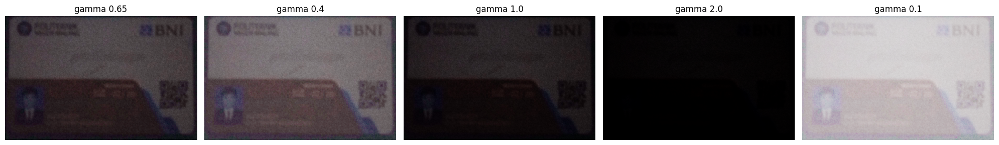

In [38]:
list_gamma=[PARAM['gamma'], 0.4,1.0,2.0,0.1]
fig,axs=plt.subplots(1,len(list_gamma),figsize=(20,5))
for ax,gamma in zip(axs,list_gamma):
  hasil_gamma=gamma_correction(img_ktm1a,gamma)
  ax.imshow(hasil_gamma)
  ax.set_title(f'gamma {gamma}')
  ax.axis('off')
plt.tight_layout()
plt.show()

# 7. Buat Simulasi Image Depth pada Citra Pribadi. Percobaan ini digunakan sebagai simulasi dari proses kuantisasi citra. Pada kuantisasi citra, pixel dapat direpresentasikan dengan n-bit kedalaman (default menggunakan 8-bit). Pada pixel 8-bit, warna yang memungkinkan adalah 256 warna, dari 0 (0000 0000) hingga 255(1111 1111). Pada pixel 7-bit, warna yang memungkinkan adalah 128 warna, dari 0 (000 0000) hingga 127 (111 1111). Kemungkinan warna didapat dari pangkat 2 jumlah bit. Jika 7bit, maka jumlah warnanya adalah 27 = 128, dst. Kuantisasi KTM1b.jpg pada kedalaman 1 sampai 7 bit dan tampilkan seluruh hasilnya.

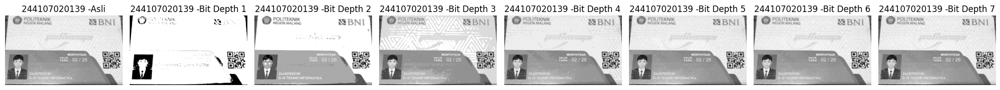

In [39]:
def simulasi_bit_depth(gray_img, bit_depth):
  level=255/(pow(2,bit_depth)-1)
  return np.round(gray_img/level)*level

ktm1b_gray=cv.cvtColor(img_ktm1b,cv.COLOR_RGB2GRAY)
fig,axs=plt.subplots(1,8,figsize=(20,10))
axs[0].imshow(ktm1b_gray,cmap='gray')
axs[0].set_title(NIM+' -Asli')
axs[0].axis('off')
for i, bit in enumerate(range(1,8), start=1):
  simulasi=simulasi_bit_depth(ktm1b_gray,bit)
  axs[i].imshow(simulasi,cmap='gray')
  axs[i].set_title(NIM+' -Bit Depth '+str(bit))
  axs[i].axis('off')
plt.tight_layout()
plt.show()

# 8. Average Denoising. Buat modul average denoising sesuai dengan rumus yang telah diberikan pada sub bab sebelumnya. Citra asli sudah disediakan pada /images/galaxy.jpg. 100 Citra dengan Gaussian Noise sudah disediakan pada /images/noises/*.jpg Anda dapat menggunakan code berikut untuk membaca semua image dalam satu folder ,gunakan modul glob (import glob).

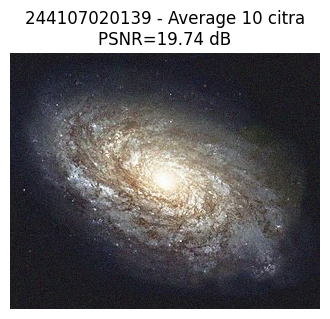

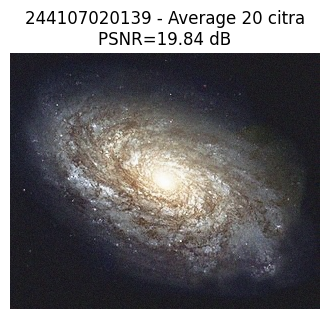

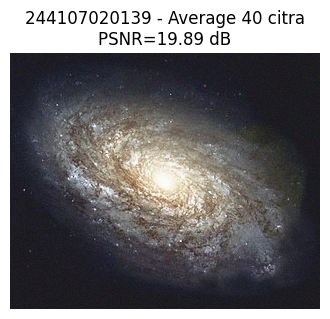

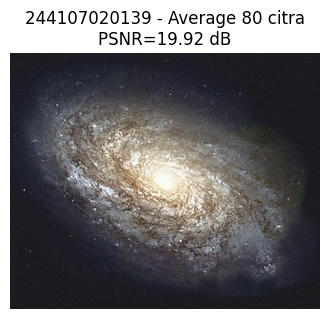

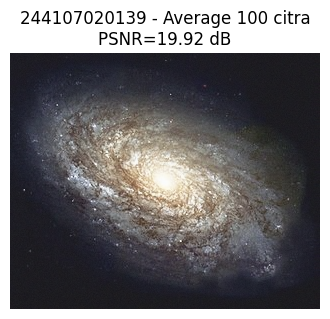

   Jumlah Citra  PSNR (dB)
0            10  19.735622
1            20  19.840488
2            40  19.892767
3            80  19.915894
4           100  19.921961


In [40]:
import glob
import pandas as pd

def PSNR(img1, img2):
  img1 = img1.astype(np.float64)
  img2 = img2.astype(np.float64)
  mse = np.mean((img1 - img2) ** 2)
  if mse == 0:
    return float('inf')
  return 20 * math.log10(255 / math.sqrt(mse))

def average_denoising(img, n):
  n = min(n, len(img))
  stack = np.stack(img[:n]).astype(np.float32)
  return np.mean(stack, axis=0).astype(np.uint8)

org_path = '/content/drive/MyDrive/PCVK/Images/244107020139/galaxy.jpg'
noise_path = '/content/drive/MyDrive/PCVK/Images/244107020139/noises/*.jpg'

org_img = cv.cvtColor(cv.imread(org_path), cv.COLOR_BGR2RGB)
cv_img = [cv.cvtColor(cv.imread(p), cv.COLOR_BGR2RGB) for p in sorted(glob.glob(noise_path))]

hasil = {}
for n in [10, 20, 40, 80, 100]:
  avg_img = average_denoising(cv_img, n)
  psnr_val = PSNR(org_img, avg_img)
  hasil[n] = psnr_val
  plt.figure(figsize=(4, 4))
  plt.imshow(avg_img)
  plt.title(NIM + f' - Average {n} citra\nPSNR={psnr_val:.2f} dB')
  plt.axis('off')
  plt.show()

print(pd.DataFrame({'Jumlah Citra': list(hasil.keys()), 'PSNR (dB)': list(hasil.values())}))

Apakah peningkatan jumlah citra selalu memberikan peningkatan PSNR yang signifikan?
<br>

<br>
Pada jumlah citra berapa peningkatan mulai tidak terlalu signifikan?<br>
Apa Kesimpulan yang
Anda peroleh dari percobaan ini?

# 9. Buat Image Masking untuk Penyamaran Data Pribadi Buat mask biner Anda sendiri yang menutup area foto wajah dan area NIM pada KTM1d.jpg, lalu gabungkan dengan citra menggunakan operator AND sehingga kedua area tersebut tersamarkan. Tuliskan koordinat kotak mask yang Anda pakai.

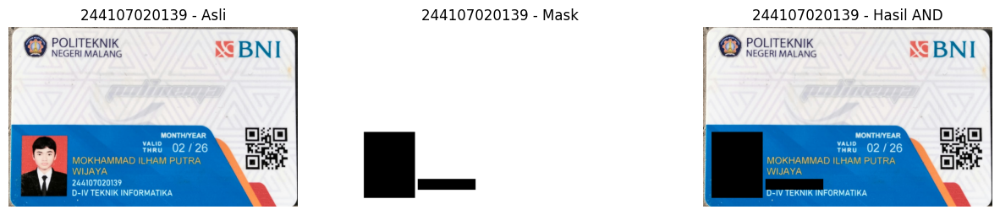

Koordinat wajah: (47, 585, 330, 950) | Koordinat NIM: (345, 845, 665, 905)


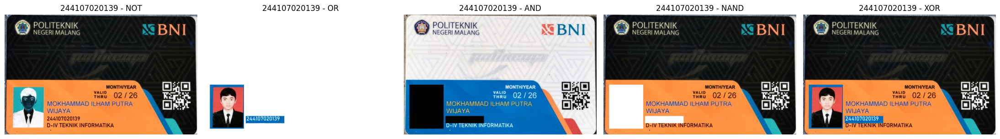

In [41]:
def buat_mask(shape, kotak_list):
    mask = np.full(shape[:2], 255, dtype=np.uint8)
    for (x1, y1, x2, y2) in kotak_list:
        mask[y1:y2, x1:x2] = 0
    return mask

img_path = '/content/drive/MyDrive/PCVK/Images/244107020139/KTM1d.jpeg'
ktm1d_bgr = cv.imread(img_path)

ktm1d = cv.cvtColor(ktm1d_bgr, cv.COLOR_BGR2RGB)

kotak_wajah = (47, 585, 330, 950)
kotak_nim   = (345, 845, 665, 905)

mask  = buat_mask(ktm1d.shape, [kotak_wajah, kotak_nim])
mask3 = cv.cvtColor(mask, cv.COLOR_GRAY2RGB)
hasil_and = cv.bitwise_and(ktm1d, mask3)

fig, axs = plt.subplots(1, 3, figsize=(15, 5))
for ax, (judul, im) in zip(axs, [('Asli', ktm1d), ('Mask', mask), ('Hasil AND', hasil_and)]):
    ax.imshow(im, cmap='gray' if judul=='Mask' else None)
    ax.set_title(NIM+' - '+judul)
    ax.axis('off')
plt.show()

print('Koordinat wajah:', kotak_wajah, '| Koordinat NIM:', kotak_nim)
op_hasil = {
    'NOT' : cv.bitwise_not(ktm1d),
    'OR'  : cv.bitwise_or(ktm1d, mask3),
    'AND' : hasil_and,
    'NAND': cv.bitwise_not(hasil_and),
    'XOR' : cv.bitwise_xor(ktm1d, mask3),
}

fig, axs = plt.subplots(1, 5, figsize=(22, 4))
for ax, (nama, im) in zip(axs, op_hasil.items()):
    ax.imshow(im); ax.set_title(NIM+' - '+nama); ax.axis('off')
plt.tight_layout(); plt.show()

# 10. Foto Malam Hari: Carilah foto malam hari yang gelap. Namun, beberapa bagian gambar memiliki detail yang sebenarnya cukup baik. Pilih salah satu metode berikut dan implementasikan pada foto tersebut (Linear Brightness, Contrast, Logarithmic Brightness, Gamma Correction). Sebutkan alasan dan resiko metode yang Anda gunakan.

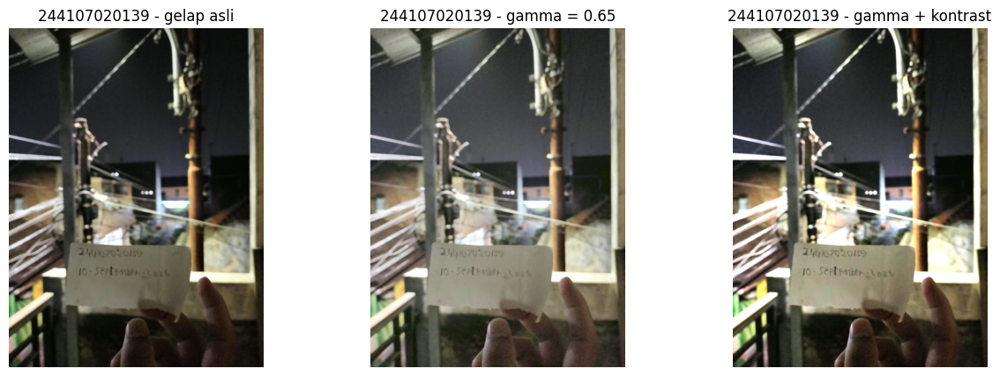

In [42]:
img_night =  '/content/drive/MyDrive/PCVK/Images/244107020139/NIGHT1.jpeg'
night_bgr=cv.imread(img_night)
night=cv.cvtColor(night_bgr,cv.COLOR_BGR2RGB)

gamma=PARAM['gamma']
a=PARAM['a']

hasil_gamma = gamma_correction(night,gamma)
hasil_kontrast = kontras(night,a)

fig, axs=plt.subplots(1, 3, figsize=(15, 5))
for ax, (judul, im) in zip(axs, [('gelap asli', night), (f'gamma = {gamma}', hasil_gamma), ('gamma + kontrast', hasil_kontrast)]):
  ax.imshow(im); ax.set_title(NIM+' - '+judul)
  ax.axis('off')
plt.show()